<a href="https://colab.research.google.com/github/Anthea05/PCVK26_03_Anthea/blob/main/week6_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
NAMA = 'Anthea Amodia Syaffah Atthaillah'
NIM = '244107020024'
print(NAMA, NIM)

Anthea Amodia Syaffah Atthaillah 244107020024


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [7]:
def convolution2d(image, kernel, stride, padding):
    h, w = image.shape
    kh, kw = kernel.shape
    out_h = (h - kh + 2 * padding) // stride + 1
    out_w = (w - kw + 2 * padding) // stride + 1
    padded_image = np.pad(image, padding, mode='constant', constant_values=0)
    output = np.zeros((out_h, out_w))
    for y in range(out_h):
        for x in range(out_w):
            region = padded_image[y * stride:y * stride + kh, x * stride:x * stride + kw]
            output[y, x] = np.sum(region * kernel)
    return output

In [8]:
img = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

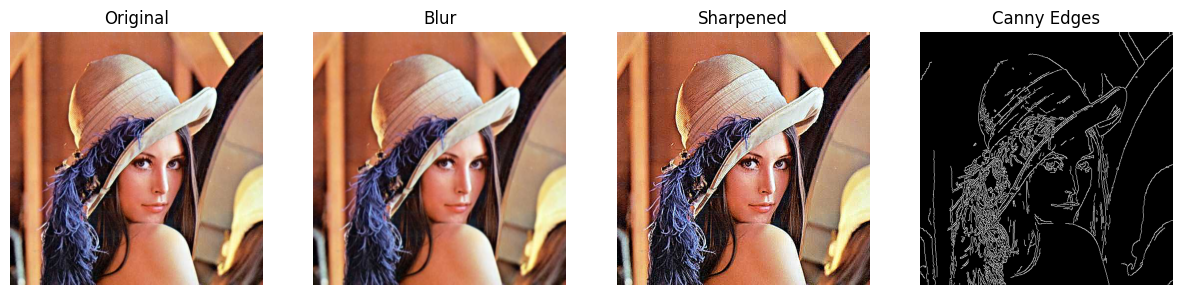

In [9]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img_lena = cv.imread("/content/drive/MyDrive/pcvk_3/images/244107020024/lena.jpg")
blur = cv.GaussianBlur(img_lena, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

daftar_gambar = [img_lena, blur, sharpened, edges]
daftar_judul = ["Original", "Blur", "Sharpened","Canny Edges"]
show_side_by_side(daftar_gambar, daftar_judul)

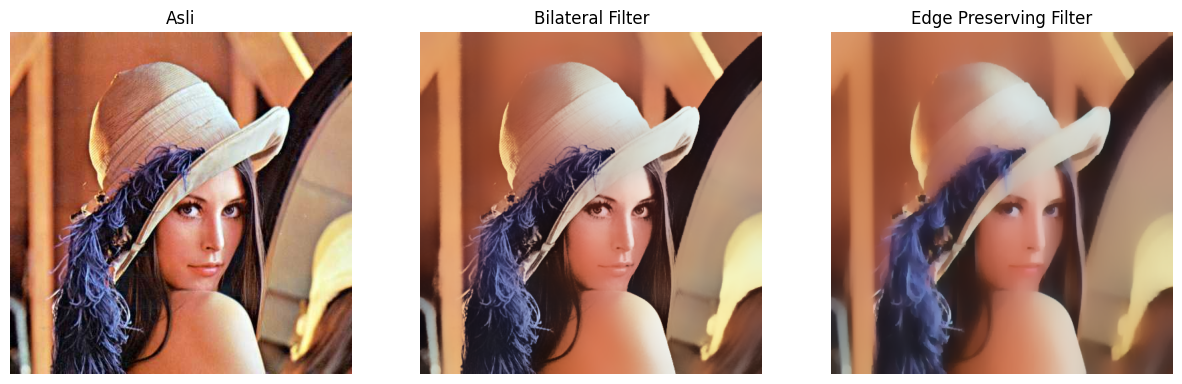

In [10]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
["Asli", "Bilateral Filter", "Edge Preserving Filter"])


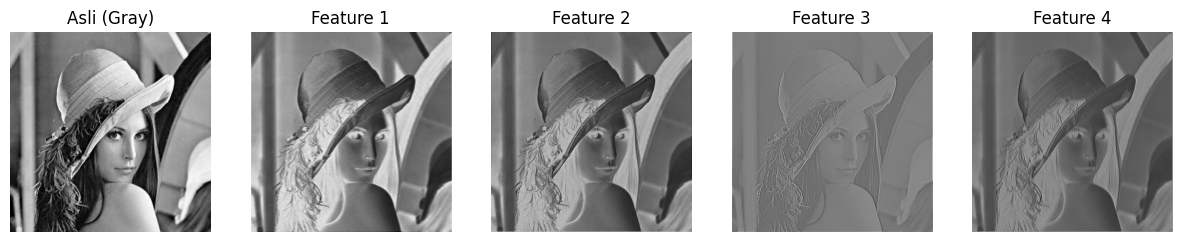

'\nkesimpulan\nBerdasarkan hasil eksekusi kode yang dilakukan berulang kali, dapat disimpulkan bahwa hasil visualisasi feature map tetap bervariasi dan tidak konsisten (terkadang terlihat seperti noise, terkadang gelap, dan lain-lain).\nHal ini disebabkan oleh fakta bahwa model SimpleCNN tersebut baru saja dibuat dan belum menjalani proses pelatihan (training). Dalam CNN, nilai bobot (angka matriks) pada filter awalnya selalu diinisialisasi secara acak (random initialization).\n'

In [11]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self) .__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

'''
kesimpulan
Berdasarkan hasil eksekusi kode yang dilakukan berulang kali, dapat disimpulkan bahwa hasil visualisasi feature map tetap bervariasi dan tidak konsisten (terkadang terlihat seperti noise, terkadang gelap, dan lain-lain).
Hal ini disebabkan oleh fakta bahwa model SimpleCNN tersebut baru saja dibuat dan belum menjalani proses pelatihan (training). Dalam CNN, nilai bobot (angka matriks) pada filter awalnya selalu diinisialisasi secara acak (random initialization).
'''

In [12]:
# ==========================
# 1. Beauty Filter
# ==========================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# ==========================
# 2. Old/Vintage Filter
# ==========================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

gambar_hasil = [img, beauty, old_img]
judul_hasil = ["Gambar Asli", "Beauty Filter", "Vintage Filter"]

show_side_by_side(gambar_hasil, judul_hasil)

In [ ]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

In [ ]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/pcvk_3/images/244107020024/djawatan.jpg.jpeg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

In [ ]:
#Filter Suasana pagi dan Kabut
# ==============================
# Step 1: Kurangi kontras & cerahkan
# ==============================
alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah Layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

Tugas!
1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”
a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).
b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.
- Noise Salt and Pepper merupakan nilai piksel yang ekstrem, yaitu titik hitam pekat (nilai 0) dan putih cerah (nilai 255).
- Median Filter berfungsi dengan cara mengurutkan nilai piksel dalam area kernel (contohnya 3x3) dari yang terendah hingga tertinggi, kemudian mengambil nilai tengahnya (median). Karena nilai 0 dan 255 termasuk nilai ekstrem, keduanya pasti berada di ujung urutan dan tidak akan pernah terpilih sebagai nilai tengah. Akibatnya, noise tersebut sepenuhnya hilang dan tergantikan oleh warna asli piksel di sekitarnya.
- Mean Filter (Blur) bekerja dengan cara menjumlahkan semua nilai piksel dan membaginya (mencari rata-rata). Jika terdapat titik putih (255) atau hitam (0) di area tersebut, nilai ekstrem tersebut akan ikut dihitung, sehingga noise tidak hilang, melainkan hanya menyebar atau membuat area sekitarnya menjadi buram/kotor.

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)
a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.
b. Terapkan pada citra yang sedikit buram (blurry).
c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.
- Kernel 3x3 memberikan ketajaman tepi yang cukup baik dan tampak alami. Gambar yang sebelumnya buram menjadi lebih jelas tanpa menambahkan terlalu banyak noise atau tekstur kasar pada bagian-bagian yang seharusnya halus.
- Kernel 5x5 menghasilkan ketajaman tepi yang sangat ekstrem dan terlihat keras (oversharpened). Meskipun garis tepinya sangat mencolok, filter ini secara signifikan meningkatkan distorsi noise. Area gambar yang dulunya mulus menjadi sangat kasar, terlihat bintik-bintik artifak, dan warnanya bisa tampak pecah.
- Kesimpulannya, Kernel yang paling ideal untuk penggunaan sehari-hari adalah Kernel 3x3, karena ukurannya memberikan keseimbangan yang tepat antara menajamkan detail.

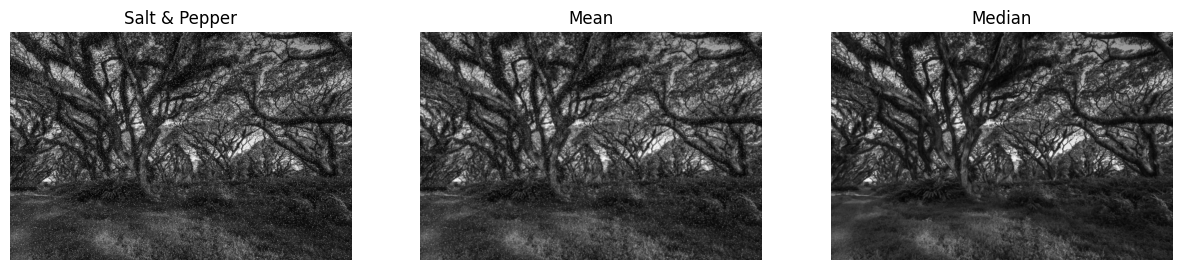

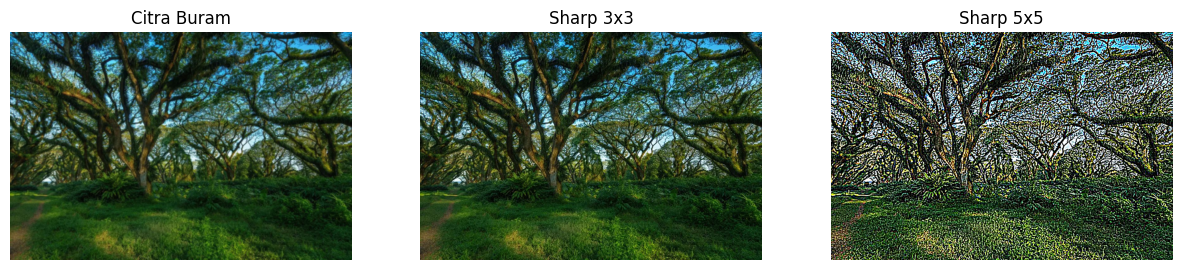

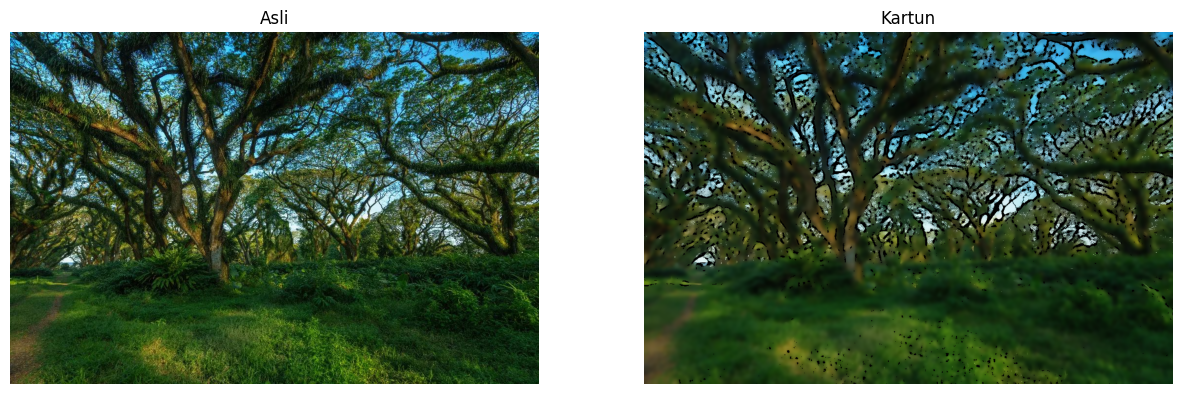

In [17]:

import cv2 as cv
import numpy as np

def salt_pepper(gambar, prob=0.05):
    out = np.copy(gambar)

    jml_salt = np.ceil(prob * gambar.size * 0.5)
    koordinat = [np.random.randint(0, i - 1, int(jml_salt)) for i in gambar.shape]
    out[tuple(koordinat)] = 255

    jml_pepper = np.ceil(prob * gambar.size * 0.5)
    koordinat = [np.random.randint(0, i - 1, int(jml_pepper)) for i in gambar.shape]
    out[tuple(koordinat)] = 0

    return out

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_noise = salt_pepper(img_gray, 0.05)

mean_res = cv.blur(img_noise, (3, 3))
median_res = cv.medianBlur(img_noise, 3)

show_side_by_side([img_noise, mean_res, median_res],
                  ["Salt & Pepper", "Mean", "Median"])


img_blur = cv.GaussianBlur(img, (5, 5), 0)

k3 = np.array([[0, -1, 0],
               [-1, 5, -1],
               [0, -1, 0]])

k5 = np.array([[-1, -1, -1, -1, -1],
               [-1, -1, -1, -1, -1],
               [-1, -1, 25, -1, -1],
               [-1, -1, -1, -1, -1],
               [-1, -1, -1, -1, -1]])

sharp3 = cv.filter2D(img_blur, -1, k3)
sharp5 = cv.filter2D(img_blur, -1, k5)

show_side_by_side([img_blur, sharp3, sharp5],
                  ["Citra Buram", "Sharp 3x3", "Sharp 5x5"])


def buat_kartun(gambar):
    warna = gambar
    for i in range(3):
        warna = cv.bilateralFilter(warna, 9, 75, 75)

    abu = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY)
    abu_blur = cv.medianBlur(abu, 7)
    tepi = cv.adaptiveThreshold(abu_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

    hasil = cv.bitwise_and(warna, warna, mask=tepi)
    return hasil

hasil_kartun = buat_kartun(img)
show_side_by_side([img, hasil_kartun], ["Asli", "Kartun"])